# Exploratory Data Analysis (EDA)

The purpose of this notebook is to verify the contents of the iWildCAM dataset for the Mexican Gray Wolf Recognition Model project. The targets of this notebook are outlined in the list below.

1. **Target 1: Class Distribution and Representation:** Count the amount of images per dataset, checking if the dataset is balanced 
2. **Target 2: Data Integrity and Channel Auditing:** Ensure that there are no corrupted files. Check if any of the images are gray-scaled. If any of the images are grayscaled, then count the amount for both RGB and grayscaled images.
3. **Target 3: Geometry and Aspect Ratio:** Footage may have been taken from different trail camera models, thus, profile structural variations in pixels across different camera models to design an optimal resizing, padding, or crop augmentation strategies.
4. **Target 4: Spatiotemporal Bursts and Data Leakage Prevention:** Trail Camera footage of animals may be taken in bursts, creating highly similar images. Thus, a problem occurs if such images were split amongst training and testing dataset

## Libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed


## Graphics Configuration and Hardware Allocation

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

NUM_WORKERS = 8 #cores

CSV_PATH = "/home/greatgilbertsoco/WolfDetect/data/train.csv"
df = pd.read_csv(CSV_PATH)
IMAGE_DIR = Path("/home/greatgilbertsoco/WolfDetect/data/train_images")

print(f"Environment ready. Hardware assigned: {NUM_WORKERS} cores are reserved")

Environment ready. Hardware assigned: 8 cores are reserved


## TARGET 1: Class Distribution and Representation Assessment

Starting parallel verification on 196299 images...

--- VERIFIED CLASS DISTRIBUTION ---
        Class  Count
        empty 131457
      opossum  14108
      raccoon   8623
       coyote   7205
       rabbit   7054
         deer   6102
       bobcat   5865
          cat   4759
     squirrel   3398
          dog   3035
       rodent   2206
        skunk   1361
          fox   1093
mountain_lion     33


/tmp/ipykernel_11170/3425551825.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='Count', y='Class', palette='viridis')


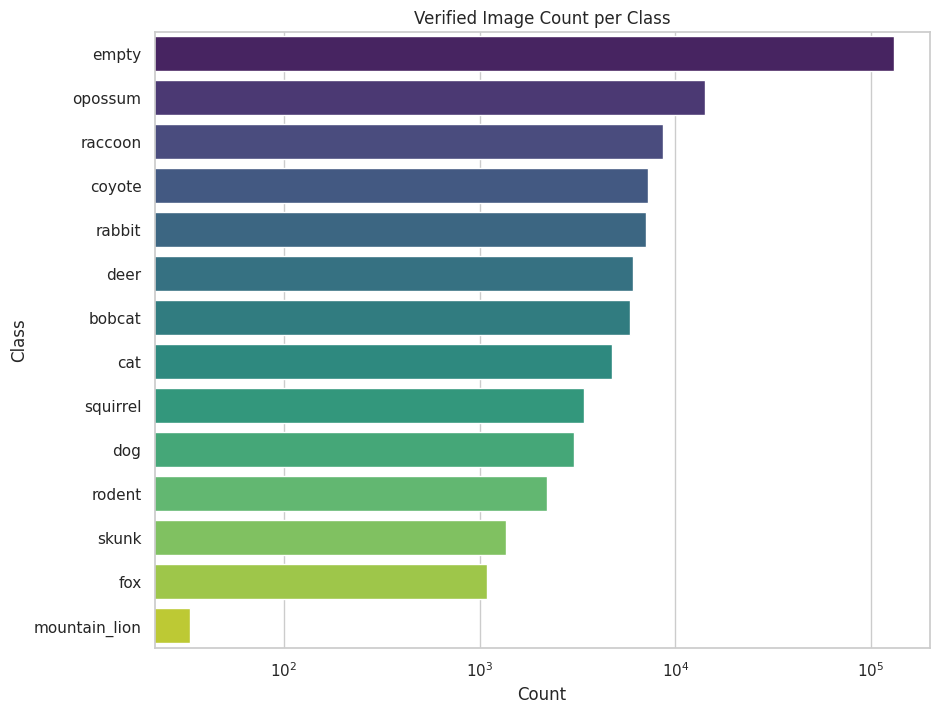

In [3]:
label_map = {
    0: 'empty', 1: 'deer', 2: 'moose', 3: 'squirrel', 4: 'rodent',
    5: 'small_mammal', 6: 'elk', 7: 'pronghorn_antelope', 8: 'rabbit',
    9: 'bighorn_sheep', 10: 'fox', 11: 'coyote', 12: 'black_bear',
    13: 'raccoon', 14: 'skunk', 15: 'wolf', 16: 'bobcat', 17: 'cat',
    18: 'dog', 19: 'opossum', 20: 'bison', 21: 'mountain_goat', 22: 'mountain_lion'
}

file_to_label = dict(zip(df['file_name'], df['category_id']))

def verify_and_get_label(file_name):
    """
    Worker function: Verifies integrity and uses dictionary for O(1) lookup.
    """
    file_path = IMAGE_DIR / file_name
    try:
        with Image.open(file_path) as img:
            img.verify()
        
        # Get category_id from the dictionary
        cat_id = file_to_label.get(file_name)
        # Map to human-readable name
        return label_map.get(cat_id, 'unknown')
    except Exception:
        return None

file_list = df['file_name'].tolist()

print(f"Starting parallel verification on {len(file_list)} images...")

with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
    valid_names = list(filter(None, executor.map(verify_and_get_label, file_list)))

valid_df = pd.DataFrame({'name': valid_names})
class_counts = valid_df['name'].value_counts().reset_index()
class_counts.columns = ['Class', 'Count']

print("\n--- VERIFIED CLASS DISTRIBUTION ---")
print(class_counts.to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=class_counts, x='Count', y='Class', palette='viridis')
plt.title("Verified Image Count per Class")
plt.xscale('log')
plt.savefig('iWildCam_ClassDistribution.png') 
plt.show()

#### Notes:
As noted from this graph, there are no images for the Wolf class although there are a large amount of images for dogs, coyotes and foxes. The dataset will be utilized because of the problem of highly similiar species, however, it must be supplemented with another dataset that has Gray Wolf images. As for Target 1, the dataset is imbalanced given the unequal imagery amount per class.

## TARGET 2: File Integrity and Channel Auditing

In [4]:
def inspect_image(file_name):
    """
    This function audits the channels for all images in the dataset
    """

    file_path = IMAGE_DIR / file_name
    try:
          with Image.open(file_path) as img:
                img.verify()
                with Image.open(file_path) as img_check:
                    mode = img_check.mode #Can be RGB, L, etc

                cat_id = img_check.mode
                label = label_map.get(cat_id, "unknown")
                return label, mode
    except Exception:
        return None, None


print(f"Starting inspection with {NUM_WORKERS} workers...")
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    chunksize = 100 
    results = list(tqdm(
        executor.map(inspect_image, file_list, chunksize=chunksize), 
        total=len(file_list),
        desc="Processing Images"
    ))

Starting inspection with 8 workers...


Processing Images: 100%|██████████| 196299/196299 [00:30<00:00, 6486.93it/s] 


In [5]:
df_results = pd.DataFrame(results, columns=['Label', 'Mode'])
df_results['file_name'] = file_list

# Merge with the original dataframe to get the correct category_id
df_audit_fixed = pd.merge(df_results, df[['file_name', 'category_id']], on='file_name')

# Map the category_id to the label name
df_audit_fixed['Class'] = df_audit_fixed['category_id'].map(label_map)

# Now generate the correct crosstab
audit_summary = pd.crosstab(df_audit_fixed['Class'], df_audit_fixed['Mode'])
print(audit_summary)

Mode             L     RGB
Class                     
bobcat         105    6284
cat              0    4759
coyote         308    6913
deer             6    6096
dog              7    3028
empty           31  131426
fox              6    1087
mountain_lion    0      33
opossum          0   14112
rabbit           0    7322
raccoon          5    8618
rodent           0    2234
skunk          100    1261
squirrel         0    3410


#### Notes:
Most of the images are in the RGB format with 568 of these images being grayscale. Such images can undergo conversion to RGB to keep the format consistent.

## TARGET 3 : Geometry and Aspect Ratio Footing

--- GEOMETRY STATISTICS ---
          width         height   aspect_ratio
count  196299.0  196299.000000  196299.000000
mean     1024.0     747.486600       1.369948
std         0.0       3.128948       0.005585
min      1024.0     747.000000       1.333333
25%      1024.0     747.000000       1.370817
50%      1024.0     747.000000       1.370817
75%      1024.0     747.000000       1.370817
max      1024.0     768.000000       1.370817


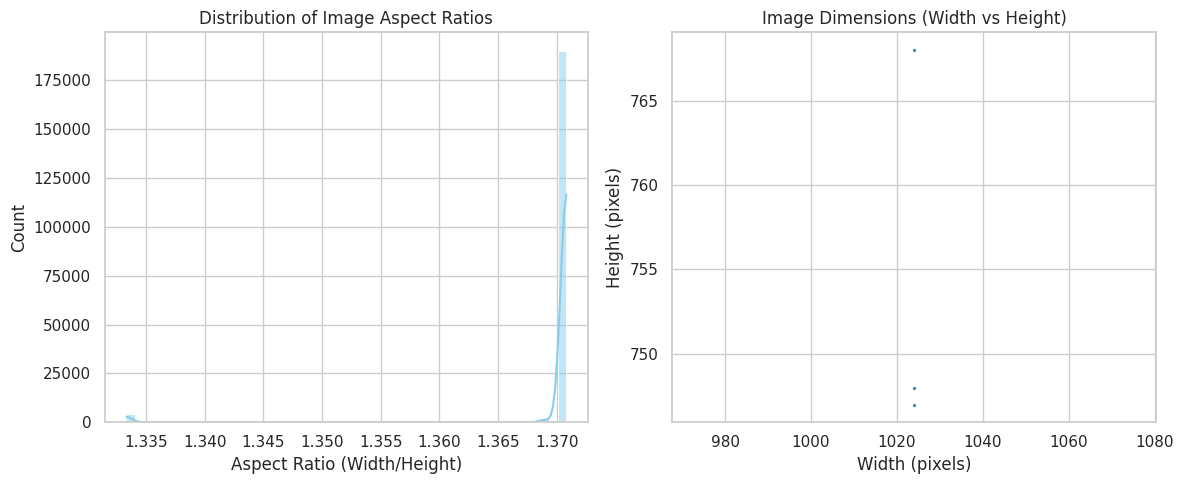

In [6]:
# Calculate Aspect Ratio by diving width by height of each image
df['aspect_ratio'] = df['width'] / df['height']

print("--- GEOMETRY STATISTICS ---")
print(df[['width', 'height', 'aspect_ratio']].describe())

plt.figure(figsize=(12, 5))

# Plot Aspect Ratio Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['aspect_ratio'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Aspect Ratio (Width/Height)")

# Plot Width vs Height Scatter
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='width', y='height', alpha=0.3, s=5)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.savefig('geometry_analysis.png')
plt.show()

#### Notes:
The Aspect Ratio is mostly consistent with the average of 1.369; most images are 1024 x 747 while a few are 1024 x 768. To overcome this issue, resizing can conducted.

## TARGET 4 : Spatiotemporal Burst and Data Leakage Prevention

--- SEQUENCE LENGTH DISTRIBUTION ---
Number of Images in Sequence | Count of Sequences
1     122856
2       1890
3      22404
4         69
5        375
6          5
9          6
12        18
Name: count, dtype: int64


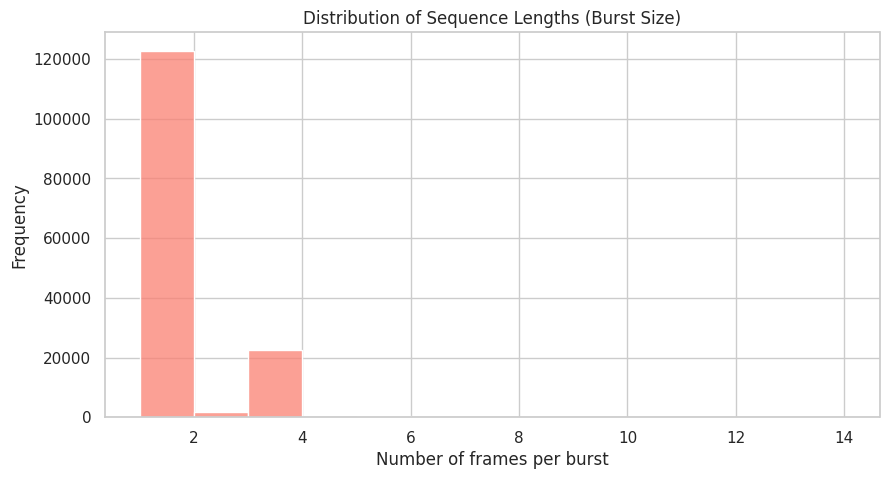

In [8]:
# Check the amount of frames in a typical sequence
seq_lengths = df.groupby('seq_id')['frame_num'].count()

sequence_distribution = df.groupby('seq_id').size().value_counts().sort_index()

print("--- SEQUENCE LENGTH DISTRIBUTION ---")
print("Number of Images in Sequence | Count of Sequences")
print(sequence_distribution)

plt.figure(figsize=(10, 5))
sns.histplot(seq_lengths, bins=range(1, 15), kde=False, color='salmon')
plt.title("Distribution of Sequence Lengths (Burst Size)")
plt.xlabel("Number of frames per burst")
plt.ylabel("Frequency")
plt.show()

#### Notes: 
There is a significant part of the data belonging to three image burst. This, indicates the need that when splitting the data into training and testing sets, the split should be done by sequence rather than the individual frame to prevent visually identical images with different IDs in the same sequence from ending up in both sets. This is to minimize the chance of the model overfitting

## Conclusion and Recommendations
This EDA was conducted on the iWildCam2019 dataset in order to verify its contents according to whether the dataset is balanced, how much of the data is RGB or other formats, the size of each image is consitent, and how much of the data belongs to a specific amount of bursts. Based on the findings, the recommendations for developing the model are made below. 

1. Because the dataset is imbalanced, a Weight Loss function should be applied, highlighting to the model the importance of classes with only a few images (ex: Mountain Lions)
2. Convert the few grayscale images into RGB.
3. Resize the images that have sizes of 1024 x 768 into 1024 x 747.
4. Split the images by sequence rather than individually.